In [82]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles

import tensorflow 
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Input,BatchNormalization,Activation

In [2]:
# In this notebook we will look how come batch normalization effects the model performance and improves it 

In [3]:
# Basically from pov we always used to do normalization for faster convergence in ann models beforehand ,
# now we take it even one step further and now the outputs from the neurons of a layer is also normalized when sent to another , so we converge 
# even faster

In [ ]:
# The setup will be simple we will be using a concentric cirles dataset and train the model with and 
# without batch normalization to look for performance

In [5]:
# Creating the dataset

In [68]:
X, y = make_circles(n_samples=500, factor=0.45, noise=0.175, random_state=42)

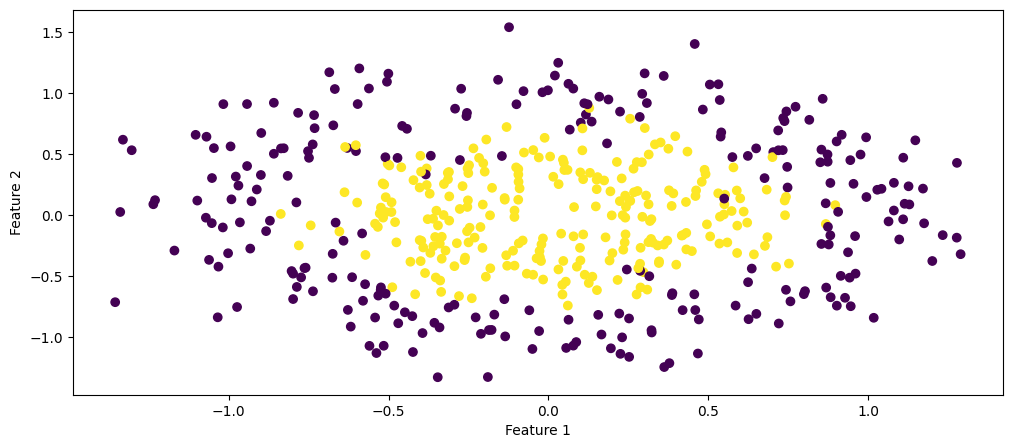

In [69]:
# Now let's visualize it 
plt.figure(figsize=(12,5))
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=4)

In [71]:
# Now model training without batch normalization

In [72]:
model = Sequential()
model.add(Input(shape=(X.shape[1],)))
model.add(Dense(10,activation='relu'))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [73]:
# Now let's skim the summary to know what amount of parameters we are dealing with
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [74]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy']) # Model compiling

In [75]:
# Now lets run the model
history_1 = model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100


13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5375 - loss: 0.6911 - val_accuracy: 0.5300 - val_loss: 0.6882
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5200 - loss: 0.6870 - val_accuracy: 0.5800 - val_loss: 0.6844
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5300 - loss: 0.6832 - val_accuracy: 0.5900 - val_loss: 0.6806
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5125 - loss: 0.6794 - val_accuracy: 0.5900 - val_loss: 0.6765
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5175 - loss: 0.6753 - val_accuracy: 0.6000 - val_loss: 0.6725
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5425 - loss: 0.6710 - val_accuracy: 0.6100 - val_loss: 0.6679
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.5550 - loss: 0.6660 - val_accuracy: 0.5900 - val_loss: 0.6628
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.5925 - loss: 0.6612 - val_accuracy: 0.6400 - val_l

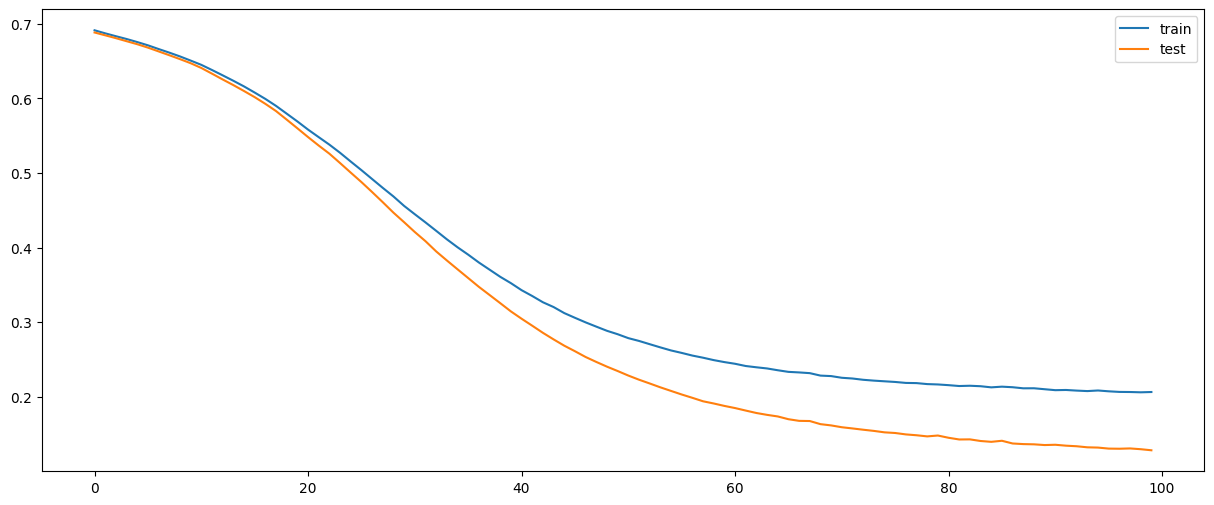

In [76]:
# Also now let's plot the loss and val_loss to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history_1.history['loss'],label='train')
plt.plot(history_1.history['val_loss'],label='test')
plt.legend()
plt.show()

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 58s 2ms/step


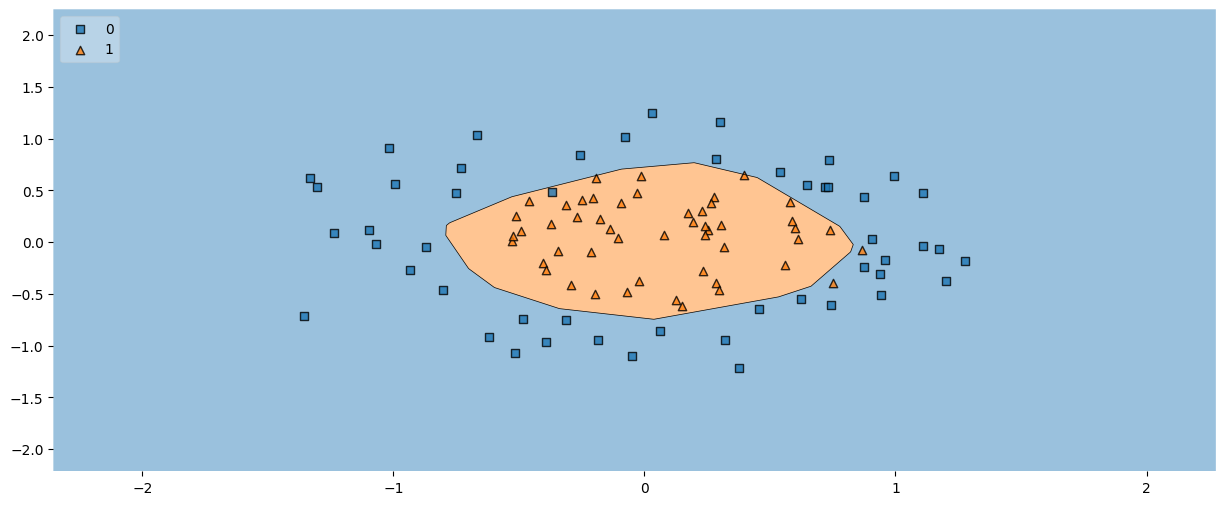

In [77]:
# Now let's checkout the model performance by plotting it's boundary using plot_decision_regions
plt.figure(figsize=(15,6))
plot_decision_regions(X_test,y_test,clf=model,legend=2)
plt.show()

In [78]:
# As we can see the amount of loss across epoch is gradual and that also , model seems to overfit a bit in the training stage 

In [79]:
# Now let's look what happens with batch normalization

In [ ]:
# The only difference seen here is we will be adding batch_normalization beneath each hidden layer when making ann

model = Sequential()

model.add(Input(shape=(X.shape[1],)))

model.add(Dense(10))
model.add(BatchNormalization()) # < That's it for all hidden layers
model.add(Activation('relu')) # Isolate the activation function so we normalize z before a , but we can also normalize afterwards which is another method.

model.add(Dense(10))
model.add(BatchNormalization())
model.add(Activation('relu'))

model.add(Dense(1,activation='sigmoid'))

In [83]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 10)             │            40 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 231 (924.00 B)

 Trainable params: 191 (764.00 B)

 Non-trainable params: 40 (160.00 B)

In [ ]:
# We can clearly see the number of non trainable params as 40
# These parameters : are moving_mean and moving_variance

In [ ]:
'''
During Training: 
    As batches of data fly forward through the network, 
    Batch Norm calculates the actual mean and variance of that specific batch. 
    It then uses a moving average formula to steadily update the moving_mean and moving_variance behind the scenes.
    
During Testing/Prediction: 
    When you evaluate your test data or make a single prediction, 
    you don't have a whole "batch" of data to calculate a mean from. 
    Instead, the model turns off batch calculations and uses these frozen moving_mean and moving_variance values to normalize your test data.
'''

In [85]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy']) # Model compiling

In [86]:
# Now lets run the model
history_2 = model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - accuracy: 0.6675 - loss: 0.6759 - val_accuracy: 0.6000 - val_loss: 0.6739
Epoch 2/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.7200 - loss: 0.5843 - val_accuracy: 0.6900 - val_loss: 0.6671
Epoch 3/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8175 - loss: 0.5073 - val_accuracy: 0.6700 - val_loss: 0.6594
Epoch 4/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.8300 - loss: 0.4760 - val_accuracy: 0.6400 - val_loss: 0.6509
Epoch 5/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8275 - loss: 0.4349 - val_accuracy: 0.6300 - val_loss: 0.6423
Epoch 6/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8450 - loss: 0.4205 - val_accuracy: 0.6100 - val_loss: 0.6334
Epoch 7/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.8725 - loss: 0.3579 - val_accuracy: 0.6100 - val_loss: 0.6232
Epoch 8/100
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8850 - loss: 0.3439 - val_accuracy: 0.

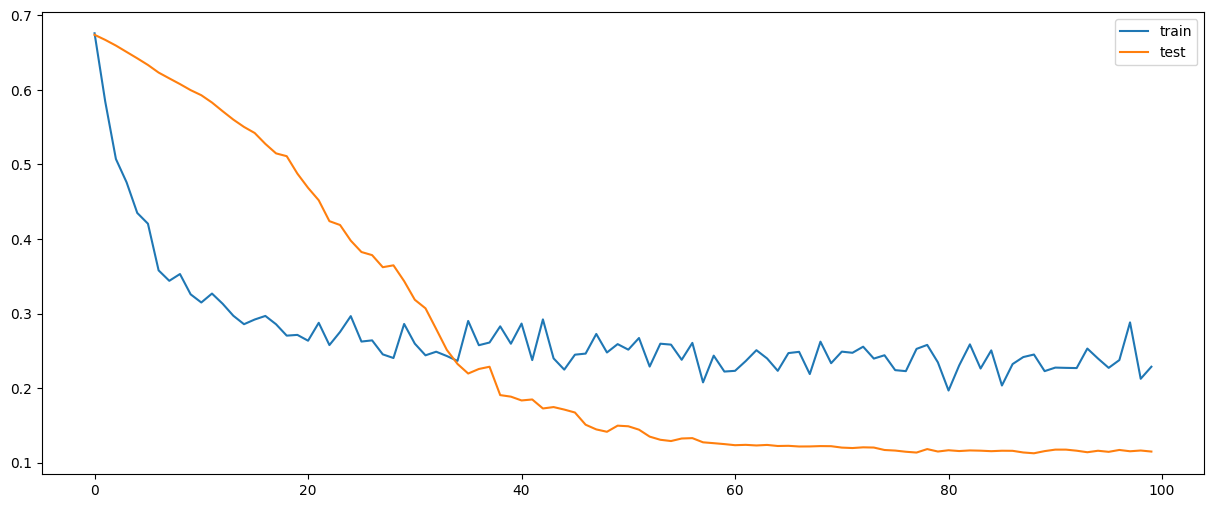

In [87]:
# Also now let's plot the loss and val_loss to understand what happened
plt.figure(figsize=(15,6))
plt.plot(history_2.history['loss'],label='train')
plt.plot(history_2.history['val_loss'],label='test')
plt.legend()
plt.show()

28125/28125 ━━━━━━━━━━━━━━━━━━━━ 59s 2ms/step


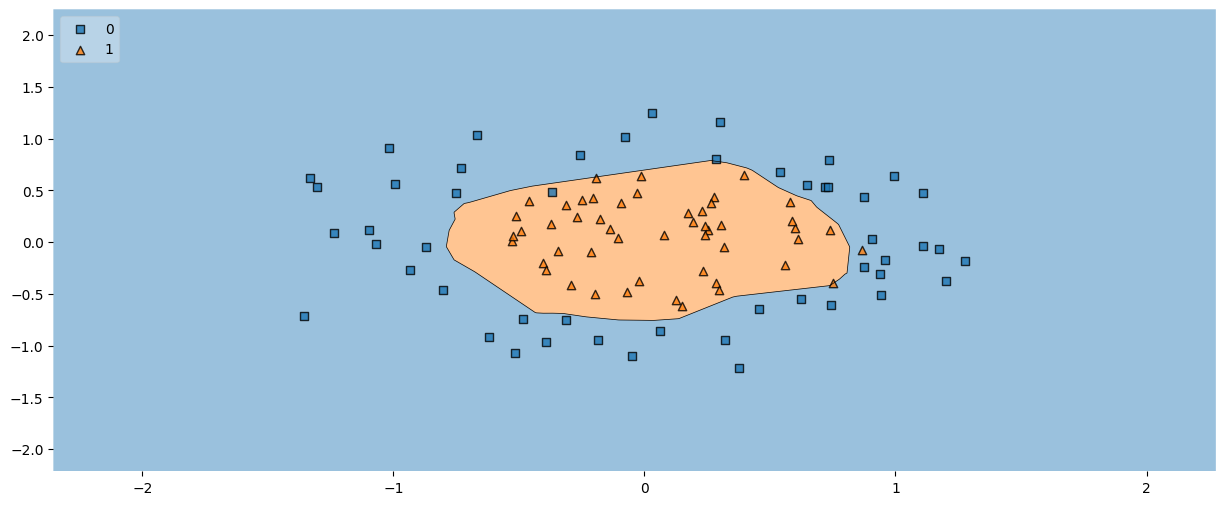

In [88]:
# Now let's checkout the model performance by plotting it's boundary using plot_decision_regions for this model too
plt.figure(figsize=(15,6))
plot_decision_regions(X_test,y_test,clf=model,legend=2)
plt.show()

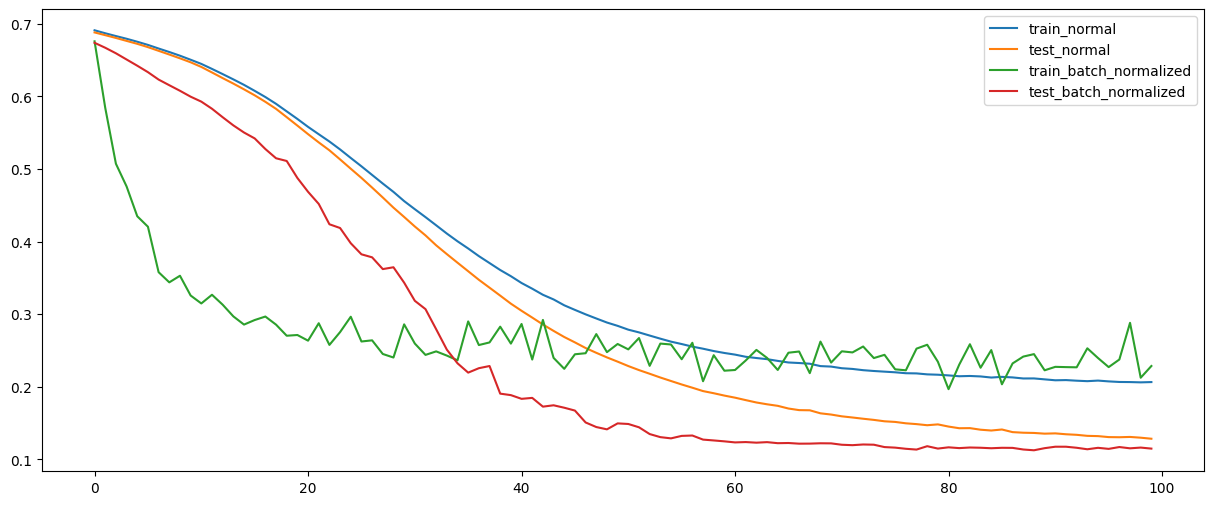

In [89]:
# Also now let's plot the loss for both the models 
plt.figure(figsize=(15,6))
plt.plot(history_1.history['loss'],label='train_normal')
plt.plot(history_1.history['val_loss'],label='test_normal')
plt.plot(history_2.history['loss'],label='train_batch_normalized')
plt.plot(history_2.history['val_loss'],label='test_batch_normalized')
plt.legend()
plt.show()

In [90]:
# We can clearly see how with the help of batches our model was able to converge faster with lower epochs using batch_normalization